In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

In [2]:
from sklearn.datasets import make_moons
X,y = make_moons(100,noise = 0.25,random_state = 2)

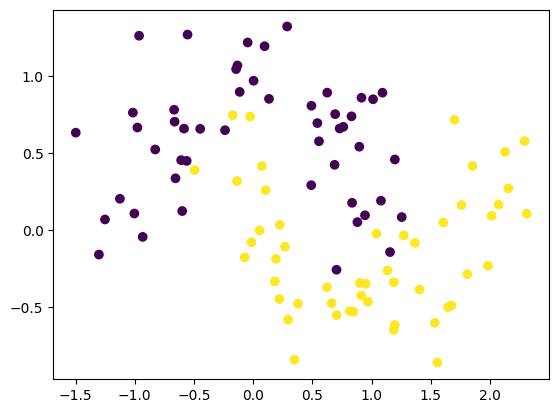

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c = y)
plt.show()

In [4]:
model1 = Sequential()

model1.add(Dense(128,input_dim =2,activation = 'relu'))
model1.add(Dense(128,activation = 'relu'))
model1.add(Dense(1,activation = 'sigmoid'))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam = Adam(learning_rate = 0.01)
model1.compile(loss = 'binary_crossentropy',optimizer = adam,metrics = ['accuracy'])
history1 = model1.fit(X,y,epochs = 2000,validation_split = 0.2,verbose = 0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

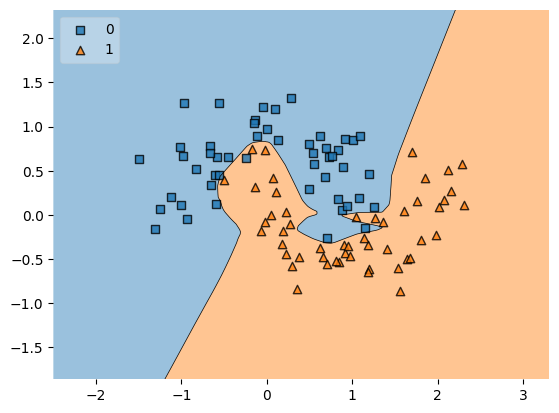

In [6]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'),clf = model1,legend = 2)

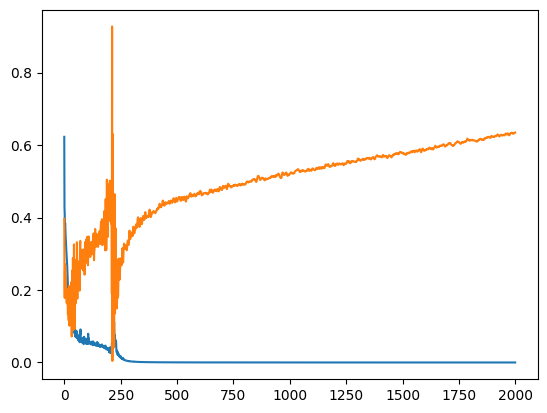

In [7]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.show()

In [8]:
model2 = Sequential()

model2.add(Dense(128,activation='relu',input_dim = 2,kernel_regularizer = tf.keras.regularizers.l2(0.05)))
model2.add(Dense(128,activation='relu',kernel_regularizer = tf.keras.regularizers.l2(0.02)))
model2.add(Dense(1,activation = 'sigmoid'))

In [9]:
adam = Adam(learning_rate = 0.01)
model2.compile(loss = 'binary_crossentropy',optimizer = adam,metrics = ['accuracy'])
history2 = model2.fit(X,y,epochs = 2000,validation_split = 0.2,verbose = 0)

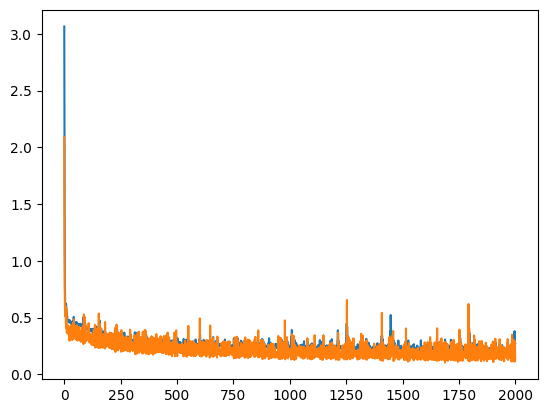

In [10]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

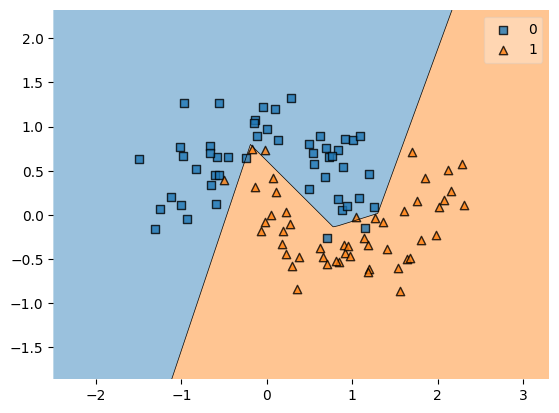

In [13]:
plot_decision_regions(X,y.astype('int'),clf = model2)